In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

Io mi sono concentrato sul profilo delle madri nel tempo, in particolare l'età al parto e alcuni fattori sociali.
Dopo aver caricato le librerie che utilizzerò durante l'analisi, importo il csv con i nati di ogni anno divisi per fascia d'età della madre.

In [2]:
# carico il file csv dei nati per fascia d'età della madre
df = pd.read_csv('/Users/alessioafrica/Downloads/Boolean/Progetto finale/Data/Nati per età madre e totale nati.csv')
df.info()
df.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Area             76 non-null     object
 1   Anno             76 non-null     int64 
 2   Nati             76 non-null     int64 
 3   Meno di 15 anni  76 non-null     int64 
 4   15-19            76 non-null     int64 
 5   20-24            76 non-null     int64 
 6   25-29            76 non-null     int64 
 7   30-34            76 non-null     int64 
 8   35-39            76 non-null     int64 
 9   40-44            76 non-null     int64 
 10  45-49            76 non-null     int64 
 11  50 anni e più    76 non-null     int64 
dtypes: int64(11), object(1)
memory usage: 7.3+ KB


,Area,Anno,Nati,Meno di 15 anni,15-19,20-24,25-29,30-34,35-39,40-44,45-49,50 anni e più
70,Italia,2019,420084,6,5173,29567,92997,143169,107921,33330,3565,463
75,Italia,2024,369944,3,3549,22913,73970,131639,100819,30035,3670,549
42,Italia,1991,562787,6,17150,115214,214262,149251,56021,10537,345,1
68,Italia,2017,458151,7,6130,33857,103072,153471,116859,36524,3468,387
17,Italia,1966,979940,307,51614,233770,320905,216243,118380,35825,2855,41


In [3]:
# creo una lista con le varie fasce d'età
eta_cols = ['Meno di 15 anni', '15-19', '20-24', '25-29',
            '30-34', '35-39', '40-44', '45-49', '50 anni e più']

# creo un dizionario con il valore numerico centrale delle fasce d'età (mi servirà gestirli come int per calcolare la media ponderata)
eta_mappa = {
    'Meno di 15 anni': 14, '15-19': 17, '20-24': 22, '25-29': 27,
    '30-34': 32, '35-39': 37, '40-44': 42, '45-49': 47, '50 anni e più': 52
}


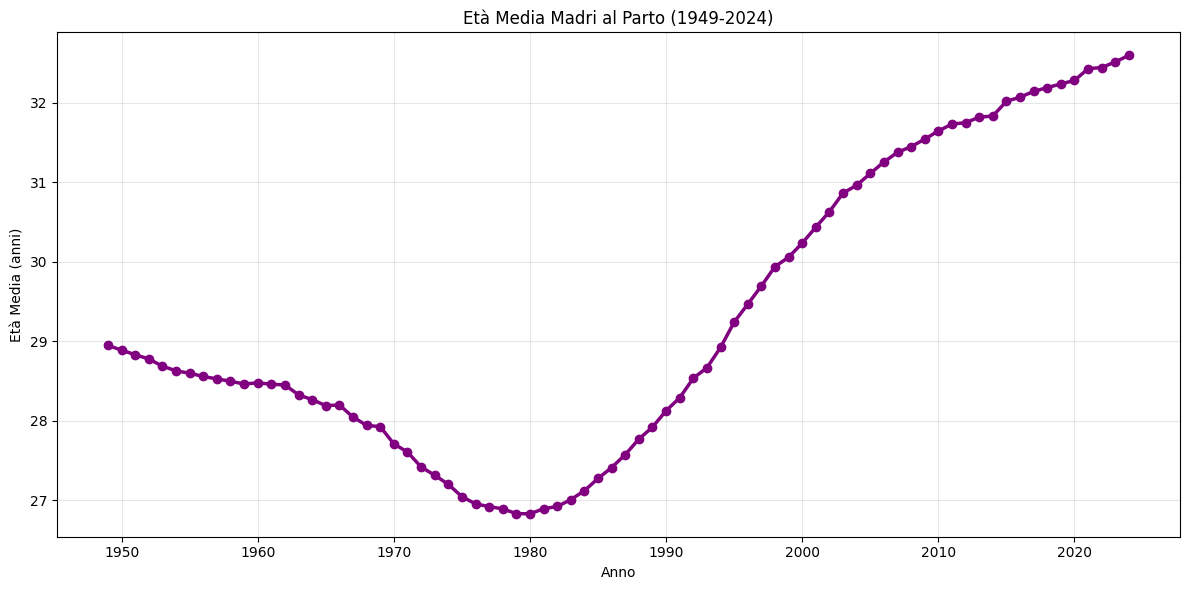

In [4]:
# Calcolo dell'età media per ogni anno
eta_media_per_anno = [] #creo una lista vuota
for idx, row in df.iterrows(): #ciclo che fa scorrere il dataframe anno per anno
    anno = row['Anno'] #ad ogni iterazione assegno l'anno alla variabile omonima
    nascite_fascia = row[eta_cols].values #assegno a nascite_fascia il numero di nati per ogni fascia d'età
    eta_fascia = list(eta_mappa.values()) #assegno ad eta_fascia l'età centrale di ogni fascia

    # Media ponderata pesata sul numero delle nascite
    total_nascite = row['Nati'] #assegno a total_nascite il valore del totale dei nati
    if total_nascite > 0: #evito errori di divisioni per zero
        eta_media = np.average(eta_fascia, weights=nascite_fascia) #calcolo la media ponderata dell'età, pesata sul numero di nati in quella fascia
        eta_media_per_anno.append({'Anno': anno, 'Età_Media': eta_media}) #aggiungo un dizionario alla lista in modo da avere l'età media corrispondente ad ogni anno

df_tempo = pd.DataFrame(eta_media_per_anno) #creo un nuovo dataframe partendo dal dizionario appena creato

# plotto il grafico
plt.figure(figsize=(12, 6))
plt.plot(df_tempo['Anno'], df_tempo['Età_Media'],
         marker='o', linewidth=2.5, color='purple')
plt.title('Età Media Madri al Parto (1949-2024)')
plt.xlabel('Anno')
plt.ylabel('Età Media (anni)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('eta_media_tempo.png', dpi=300)
plt.show()


Il primo risulato emerso è chiaro: nel corso del tempo l'età media delle madri al parto è aumentata in modo costante. Questo significa che oggi si diventa madri mediamente più tardi e quindi la maternità tende a spostarsi più avanti nel ciclo di vita.

A questo punto ho provato a collegare questo andamento con un'altra variabile: la percentuale di donne laureate sul totale dei laureati ogni anno.
Ho messo a confronto le due serie di dati nel periodo in cui i dati sono sovrapponibili: 1970/2014.

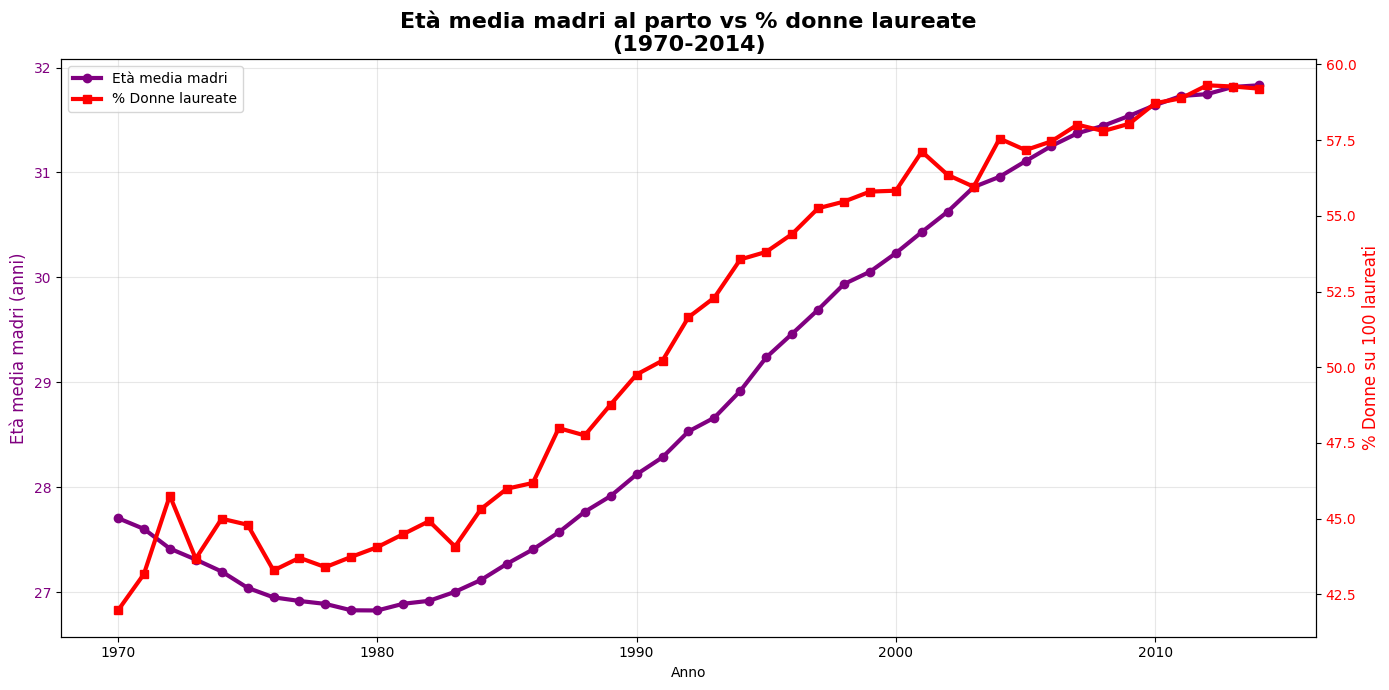

In [ ]:
donne_lauree = pd.read_csv('/Users/alessioafrica/Downloads/Boolean/Progetto finale/Data/Percentuale donne su tot laureati per anno.csv') # carico il dataset che contiene la % di donne sul totale dei laureati di ogni anno
donne_lauree['Anno'] = donne_lauree['Anno'].astype(int) #converto l'anno in int

df_tempo_1970 = df_tempo[(df_tempo['Anno'] >= 1970) & (df_tempo['Anno'] <= 2014)] #restringo il dataframe creato in precedenza con gli anni di cui possiedo il dato sui laureati


fig, ax1 = plt.subplots(figsize=(14, 7)) 

#Creo il primo linechart e personalizzo l'asse x di sinistra
ax1.plot(df_tempo_1970['Anno'], df_tempo_1970['Età_Media'],
         marker='o', linewidth=3, color='purple', label='Età media madri')
ax1.set_xlabel('Anno')
ax1.set_ylabel('Età media madri (anni)', color='purple', fontsize=12)
ax1.tick_params(axis='y', labelcolor='purple')
ax1.grid(True, alpha=0.3)

#Creo il secondo linechart
ax2 = ax1.twinx() 
ax2.plot(donne_lauree['Anno'], donne_lauree[' Donne per 100 laureati'],
         marker='s', linewidth=3, color='red', label='% Donne laureate')
ax2.set_ylabel('% Donne su 100 laureati', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Età media madri al parto vs % donne laureate\n(1970-2014)', fontsize=16, fontweight='bold')

# Legenda
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
# plt.savefig('eta_laureate_1970.png', dpi=300, bbox_inches='tight')
plt.show()


Il risultato mostra un andamento molto simile tra le due curve, suggerendo una correlazione.
Per provarla statisticamente ho effettuato il test di correlazione di Pearson, utilizzando la libreria Scipy.

In [10]:
# Test statistico
corr, p_value = pearsonr(df_tempo_1970['Età_Media'], donne_lauree[' Donne per 100 laureati']) #uso la funzione pearsonr della libreria SciPy


print(f"r = {corr:.3f}")
print(f"p-value = {p_value:.6f}")

# R → Coefficiente di correlazione di Pearson
# r = +1    → Correlazione positiva 
# r =  0    → Nessuna correlazione
# r = -1    → Correlazione negativa 
# p-value < 0.05 → correlazione statisticamente significativa e H₀ rifiutata → Il p-value è la probabilità di ottenere un risultato almeno altrettanto estremo di quello osservato (più è piccola, più è difficile che sia frutto di una coincidenza)
# H₀ (ipotesi nulla rifiutata): "Non c'è relazione tra età media e donne laureate" → se p-value <0.05 correlazione statisticamente significativa



r = 0.970
p-value = 0.000000


Il test conferma la forte correlazione.
C'è una forte correlazione positiva (r = +1) tra la percentuale di donne laureate e l'età media al parto.
Ovviamente questo non significa che la laurea sia la sola causa dell'aumento dell'età media ma suggerisce uno dei possibili fattori.
Il prolungamento dei percorsi formativi porta inevitabilmente al rinvio di alcune tappe di vita, tra cui la maternità.

Per approfondire ho infine confrontato due gruppi specifici: le madri con età compresa tra i 20 ed i 24 anni e le madri tra i 40 e i 44 anni.

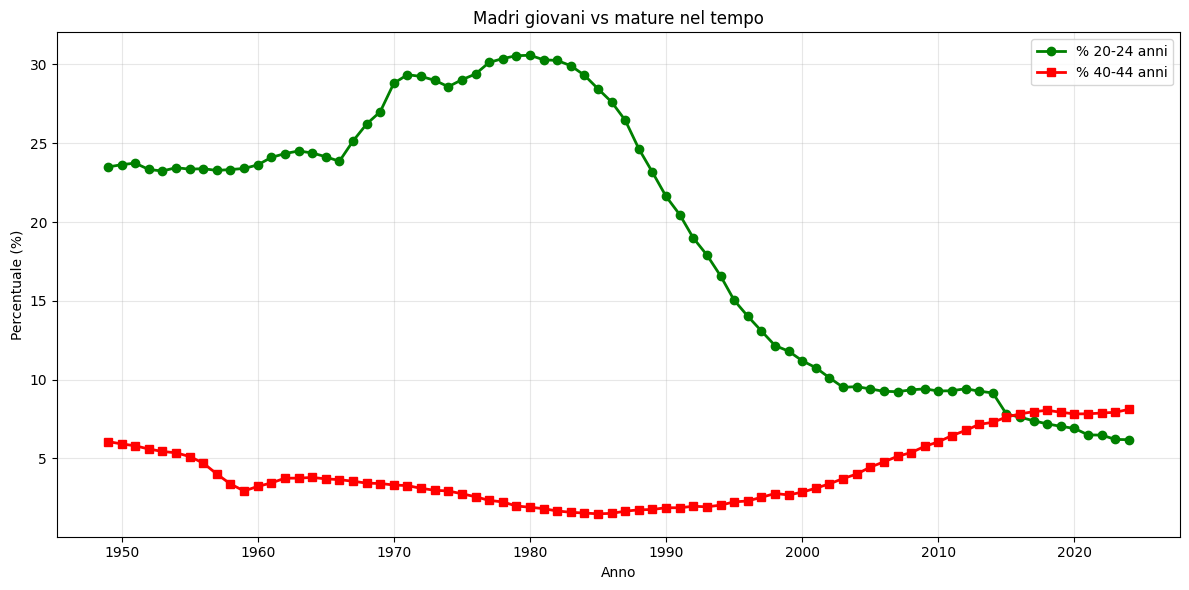

In [7]:
percentuali = [] #creo una lista nuova
for idx, row in df.iterrows(): #ciclo che fa scorrere il dataframe anno per anno
    total_nascite = row['Nati'] #assegno a total_nascite il valore del totale dei nati
    if total_nascite > 0:
        giovani = row['20-24'] / total_nascite * 100 #calcolo la percentuale di nati da madri giovani rispetto al totale
        mature = row['40-44'] / total_nascite * 100

        percentuali.append({ #creo un dizionario con l'anno e le due percentuali appena calcolate
            'Anno': row['Anno'],
            '%_Giovani_20-24': giovani,
            '%_mature_40-44': mature
        })

df_perc = pd.DataFrame(percentuali) #creo un dataframe partendo dal dizionario

plt.figure(figsize=(12, 6))
plt.plot(df_perc['Anno'], df_perc['%_Giovani_20-24'],
         marker='o', label='% 20-24 anni', color='green', linewidth=2)
plt.plot(df_perc['Anno'], df_perc['%_mature_40-44'],
         marker='s', label='% 40-44 anni', color='red', linewidth=2)
plt.title('Madri giovani vs mature nel tempo')
plt.xlabel('Anno')
plt.ylabel('Percentuale (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('percentuali_giovani_mature.png', dpi=300)
plt.show()


Questo è uno dei risultati che più mi ha stupito. Il grafico mostra quanto sia cambiata la struttura della maternità.
Dal 2016, i nati da madri di 40/44 anni sono più dei nati da madri di 20/24 anni.
Un vero e proprio ribaltamento tra due fasce d'età che storicamente hanno avuto un peso molto diverso.

I risultati della mia analisi mi portano a pensare che oggi, più che per uno scarso desiderio di avere figli, il calo della natalità sia legato a dinamiche sociali. Per i giovani è più difficile trovare la stabilità necessaria per metter sù famiglia, ed inevitabilmente chi arriva a questo obiettivo lo fa con qualche anno di ritardo rispetto al passato.